# Exploratory Data Analysis

This notebook contains the exploratory data analysis of the Irrigation Water Requirement Prediction Dataset.

The goal is to understand the structure, quality, distributions and relationships in the data before building machine learning models.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data_path = "A:/Projekty Turcja/smart-irrigation-ai/data/raw/irrigation_prediction.csv"
df = pd.read_csv(data_path)
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


## 1. Dataset Overview

In this section, the basic structure of the dataset is examined, including its dimensions, feature names and data types.

In [3]:
df.shape #zwraca liczbę wierszy i liczbę kolumn w DataFrame
df.columns #zwraca nazwy kolumn w DataFrame
df.info()
df.dtypes.value_counts() #ile mamy kolumn każdego typu 




<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  str    
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sunlight_Hours           10000 non-null  float64
 9   Wind_Speed_kmh           10000 non-null  float64
 10  Crop_Type                10000 non-null  str    
 11  Crop_Growth_Stage        10000 non-null  str    
 12  Season                   10000 non-null  str    
 13  Irrigation_Type          10000 non-null  str    
 14  Water_Source             10000 non

float64    11
str         9
Name: count, dtype: int64

## 2. Data Quality

Before analysing the relationships between variables, the dataset is checked for missing values and duplicated observations.

In [ ]:
df.isnull().sum()
df.duplicated().sum()

print("Total missing values:", df.isnull().sum().sum())
print("Duplicated rows:", df.duplicated().sum())

Total missing values: 0
Duplicated rows: 0


## 3. Target Variable Distribution

The distribution of the target variable is examined to determine how frequently each irrigation need category occurs in the dataset.

In [11]:
df["Irrigation_Need"].value_counts()

Irrigation_Need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64

In [12]:
df["Irrigation_Need"].value_counts(normalize=True) * 100 # procentowy udział każdej klasy w kolumnie

Irrigation_Need
Low       58.64
Medium    38.00
High       3.36
Name: proportion, dtype: float64

### Target Class Distribution

The target variable is imbalanced, with the High irrigation need category representing only a small proportion of the observations. This imbalance will be considered during model training and evaluation.

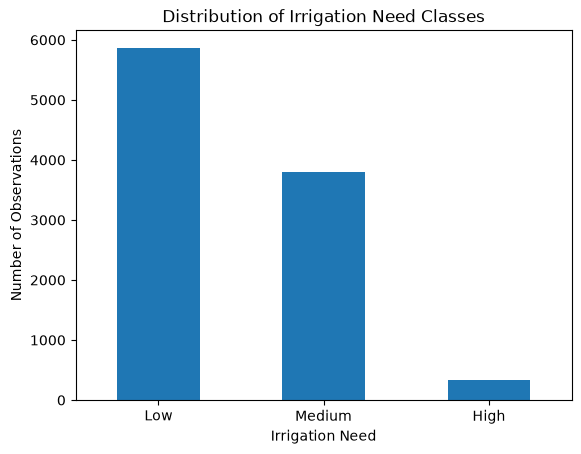

In [14]:
target_distribution = df["Irrigation_Need"].value_counts()
target_distribution.plot(kind="bar")

plt.title("Distribution of Irrigation Need Classes")
plt.xlabel("Irrigation Need")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.show()

## 4. Numerical Feature Analysis

This section examines the basic statistical properties of the numerical variables in the dataset.

In [15]:
df.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.487857,36.969207,0.944731,1.791963,26.991423,60.080339,1252.499420,7.518538,10.163545,7.598024,59.864122
std,0.979963,16.430845,0.372406,0.984202,8.664074,20.187973,715.582201,2.016077,5.670923,4.233919,34.483722
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.640000,22.860000,0.620000,0.940000,19.460000,42.855000,634.155000,5.760000,5.160000,3.950000,30.160000
50%,6.470000,37.240000,0.950000,1.780000,27.090000,60.040000,1250.335000,7.560000,10.190000,7.540000,59.630000
75%,7.350000,50.940000,1.260000,2.650000,34.500000,77.705000,1880.265000,9.260000,15.100000,11.202500,90.030000
max,8.200000,65.000000,1.600000,3.500000,42.000000,95.000000,2499.690000,11.000000,20.000000,15.000000,119.990000


### Distribution of Numerical Features

The distributions of numerical variables are examined to identify their ranges, shapes and potential unusual values.

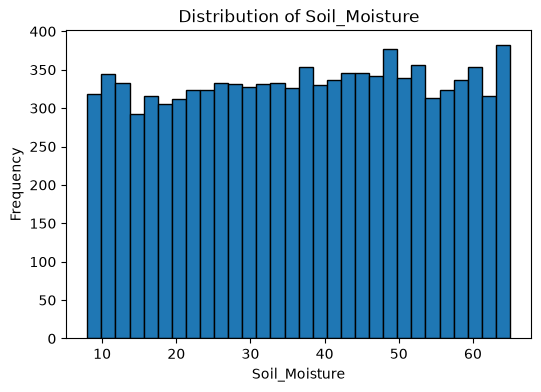

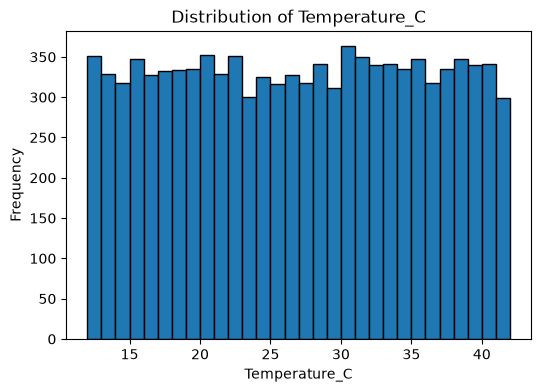

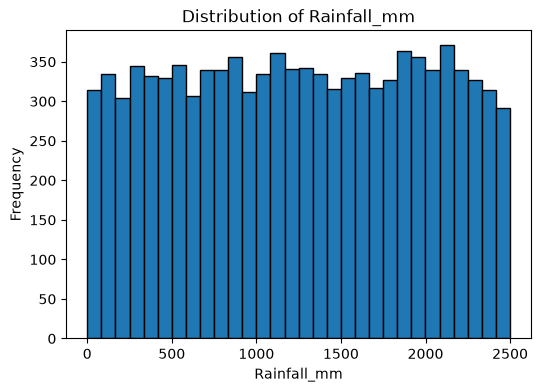

In [18]:
numerical_features = [
    "Soil_Moisture",
    "Temperature_C",
    "Rainfall_mm"
]

for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    plt.hist(df[feature], bins=30, edgecolor="black")
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

## 5. Categorical Feature Analysis

This section examines the categories present in the categorical variables and their frequencies.

In [19]:
categorical_features = df.select_dtypes(include="str").columns

for feature in categorical_features:
    print(feature, "->", df[feature].nunique()) 


Soil_Type -> 4
Crop_Type -> 6
Crop_Growth_Stage -> 4
Season -> 3
Irrigation_Type -> 4
Water_Source -> 4
Mulching_Used -> 2
Region -> 5
Irrigation_Need -> 3


In [20]:
for feature in categorical_features:
    print("\n", feature)
    print(df[feature].value_counts())
    


 Soil_Type
Soil_Type
Sandy    2536
Silt     2501
Loamy    2486
Clay     2477
Name: count, dtype: int64

 Crop_Type
Crop_Type
Rice         1711
Maize        1694
Sugarcane    1678
Potato       1663
Wheat        1659
Cotton       1595
Name: count, dtype: int64

 Crop_Growth_Stage
Crop_Growth_Stage
Harvest       2581
Vegetative    2521
Flowering     2465
Sowing        2433
Name: count, dtype: int64

 Season
Season
Rabi      3383
Kharif    3362
Zaid      3255
Name: count, dtype: int64

 Irrigation_Type
Irrigation_Type
Sprinkler    2527
Rainfed      2511
Drip         2495
Canal        2467
Name: count, dtype: int64

 Water_Source
Water_Source
River          2528
Reservoir      2513
Rainwater      2497
Groundwater    2462
Name: count, dtype: int64

 Mulching_Used
Mulching_Used
No     5013
Yes    4987
Name: count, dtype: int64

 Region
Region
South      2102
West       2017
East       1994
Central    1987
North      1900
Name: count, dtype: int64

 Irrigation_Need
Irrigation_Need
Low       5

### Distribution of Selected Categorical Features

Selected categorical variables are visualized to examine how observations are distributed across their categories.

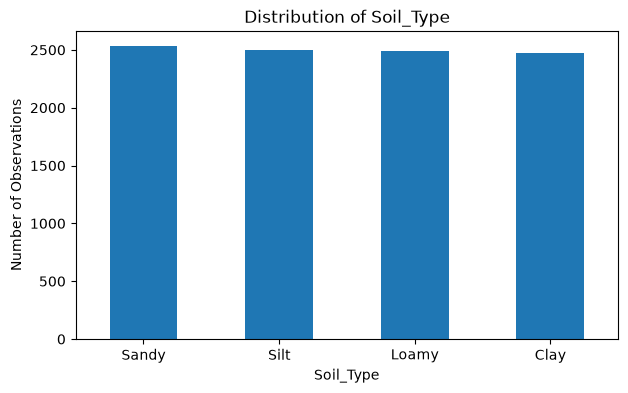

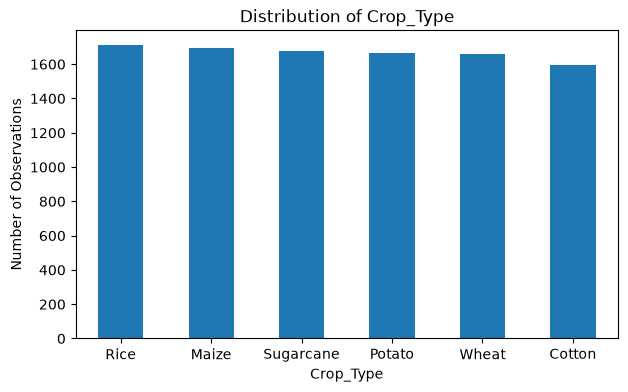

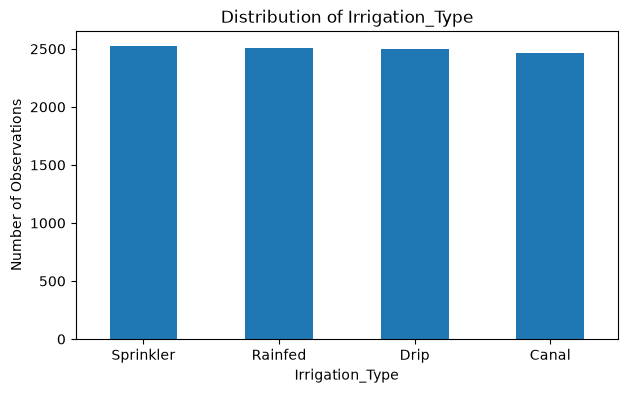

In [21]:
categorical_features_to_plot = [
    "Soil_Type",
    "Crop_Type",
    "Irrigation_Type"
]

for feature in categorical_features_to_plot:
    plt.figure(figsize=(7, 4))
    df[feature].value_counts().plot(kind="bar")

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Number of Observations")
    plt.xticks(rotation=0)
    plt.show()

## 6. Relationships with the Target Variable

This section examines how selected input features are related to the irrigation need classes.

In [ ]:
soil_target_counts = pd.crosstab(
    df["Soil_Type"],
    df["Irrigation_Need"]
)

soil_target_counts

Irrigation_Need,High,Low,Medium
Soil_Type,,,
Clay,85,1442,950
Loamy,74,1488,924
Sandy,96,1479,961
Silt,81,1455,965


In [24]:
soil_target_percent = pd.crosstab(
    df["Soil_Type"],
    df["Irrigation_Need"],
    normalize="index"
) * 100

soil_target_percent.round(2)

Irrigation_Need,High,Low,Medium
Soil_Type,,,
Clay,3.43,58.22,38.35
Loamy,2.98,59.86,37.17
Sandy,3.79,58.32,37.89
Silt,3.24,58.18,38.58
